# Event-TimeRAF Paper Claim Verification

**Mode:** artifact-backed reproducibility and claim audit.

This notebook is the executable companion to the corrected paper. It reads the immutable
`event_timeraf_final_run.zip`, verifies every manifest checksum, reconstructs the test
dataset and retrieval knowledge base, reruns every saved predictor used by M00--M11,
recomputes all paper metrics and ablations, and regenerates every manuscript figure.

## TL;DR

- The verified run contains **48,332** windows and **7,199** test origins.
- The actual SACB vector is **85-dimensional**: 23 PM2.5 + 14 weather + 9 calendar +
  39 event features. The full M09 per-horizon input is **151**, not 152.
- M04 is the strongest verified model: MSE 26.185, MAE 3.125, RMSE 5.117, R-squared 0.379.
- M09 does not beat M04 overall. M11 improves M10 MSE slightly, but its bootstrap interval
  crosses zero.
- M12 is absent from the immutable manifest-backed run and is excluded from the paper.

The notebook deliberately reuses saved model objects rather than retraining them. The full
training experiment is `01_event_timeraf_kaggle_pipeline.ipynb`; this notebook proves that
the archived models and inputs reproduce the final paper exactly and is short enough for a
live presentation.

## 1. Setup and Evidence Contract

The immutable final-run ZIP is the source of truth. A local review directory may contain
later exploratory edits, but it is not allowed to override a manifest-backed artifact.
On Kaggle, attach the final-run ZIP and the repository ZIP as notebook datasets.

In [1]:
import hashlib
import importlib.util
import json
import os
import pathlib
import re
import shutil
import subprocess
import sys
import warnings
import zipfile
from io import BytesIO
from pathlib import Path, PurePosixPath

required = {
    'dill': 'dill', 'joblib': 'joblib', 'matplotlib': 'matplotlib',
    'numpy': 'numpy', 'pandas': 'pandas', 'pyarrow': 'pyarrow',
    'seaborn': 'seaborn', 'xgboost': 'xgboost', 'yaml': 'pyyaml',
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

import dill  # Required by the archived joblib models.
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, SVG, display

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
warnings.filterwarnings('ignore', message='.*serialized model.*older version.*')

def has_source(root: Path) -> bool:
    return (root / 'src' / 'event_timeraf' / 'evaluation.py').exists()

def find_project_root() -> Path:
    override = os.environ.get('PROJECT_ROOT_OVERRIDE')
    if override:
        root = Path(override).resolve()
        if not has_source(root):
            raise FileNotFoundError(f'PROJECT_ROOT_OVERRIDE has no Event-TimeRAF source: {root}')
        return root
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if has_source(candidate):
            return candidate
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        source_file = next(kaggle_input.rglob('src/event_timeraf/evaluation.py'), None)
        if source_file is not None:
            return source_file.parents[2]
        for archive in sorted(kaggle_input.rglob('*.zip')):
            with zipfile.ZipFile(archive) as bundle:
                members = [PurePosixPath(name) for name in bundle.namelist()]
                marker = next((m for m in members if m.parts[-3:] == ('src', 'event_timeraf', 'evaluation.py')), None)
                if marker is None:
                    continue
                if any(m.is_absolute() or '..' in m.parts for m in members):
                    raise RuntimeError(f'Unsafe archive paths: {archive}')
                target = Path('/kaggle/working/event_timeraf_verification_project')
                target.mkdir(parents=True, exist_ok=True)
                prefix = marker.parts[:-3]
                for member in members:
                    relative = member.parts[len(prefix):] if member.parts[:len(prefix)] == prefix else ()
                    if relative and relative[0] in {'src', 'configs', 'paper'}:
                        bundle.extract(str(member), target)
                root = target.joinpath(*prefix)
                if has_source(root):
                    return root
    raise FileNotFoundError('Repository source not found. Attach the repository ZIP or set PROJECT_ROOT_OVERRIDE.')

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

def find_final_run_zip() -> Path:
    override = os.environ.get('FINAL_RUN_ZIP_OVERRIDE')
    candidates = [Path(override)] if override else []
    candidates.append(PROJECT_ROOT / 'event_timeraf_final_run.zip')
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        candidates.extend(sorted(kaggle_input.rglob('event_timeraf_final_run.zip')))
        candidates.extend(sorted(kaggle_input.rglob('*.zip')))
    for candidate in candidates:
        if not candidate or not candidate.exists():
            continue
        try:
            with zipfile.ZipFile(candidate) as bundle:
                names = set(bundle.namelist())
                if {'outputs/logs/run_manifest.json', 'data/processed/window_arrays.npz'} <= names:
                    return candidate.resolve()
        except zipfile.BadZipFile:
            continue
    raise FileNotFoundError('Attach event_timeraf_final_run.zip or set FINAL_RUN_ZIP_OVERRIDE.')

FINAL_RUN_ZIP = find_final_run_zip()
OUTPUT_ROOT = (
    Path('/kaggle/working/event_timeraf_verification')
    if os.name != 'nt' and Path('/kaggle/working').exists()
    else PROJECT_ROOT / 'verification_outputs'
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

class ArtifactStore:
    def __init__(self, archive: Path, cache: Path):
        self.archive = archive
        self.cache = cache

    def read_bytes(self, relative: str) -> bytes:
        with zipfile.ZipFile(self.archive) as bundle:
            return bundle.read(PurePosixPath(relative).as_posix())

    def read_json(self, relative: str):
        return json.loads(self.read_bytes(relative).decode('utf-8'))

    def read_csv(self, relative: str) -> pd.DataFrame:
        return pd.read_csv(BytesIO(self.read_bytes(relative)))

    def read_parquet(self, relative: str) -> pd.DataFrame:
        return pd.read_parquet(BytesIO(self.read_bytes(relative)))

    def read_npz(self, relative: str):
        return np.load(BytesIO(self.read_bytes(relative)))

    def materialize(self, relative: str) -> Path:
        destination = self.cache / PurePosixPath(relative)
        if not destination.exists():
            destination.parent.mkdir(parents=True, exist_ok=True)
            destination.write_bytes(self.read_bytes(relative))
        return destination

store = ArtifactStore(FINAL_RUN_ZIP, OUTPUT_ROOT / 'cache')
print({'project_root': str(PROJECT_ROOT), 'final_run_zip': str(FINAL_RUN_ZIP), 'output_root': str(OUTPUT_ROOT)})

{'project_root': 'D:\\1.msc\\ASA', 'final_run_zip': 'D:\\1.msc\\ASA\\event_timeraf_final_run.zip', 'output_root': 'D:\\1.msc\\ASA\\verification_outputs'}


## 2. Verify the Immutable Run Manifest

In [2]:
manifest = store.read_json('outputs/logs/run_manifest.json')
audit = store.read_json('outputs/audit/data_audit.json')
tsfm_status = store.read_json('outputs/logs/tsfm_gate_status.json')

integrity_rows = []
for relative, expected in manifest['artifacts'].items():
    payload = store.read_bytes(relative)
    actual_hash = hashlib.sha256(payload).hexdigest()
    integrity_rows.append({
        'artifact': relative,
        'expected_bytes': expected['bytes'],
        'actual_bytes': len(payload),
        'sha256_match': actual_hash == expected['sha256'],
    })
integrity = pd.DataFrame(integrity_rows)
display(integrity.groupby('sha256_match').size().rename('artifact_count').to_frame())
assert integrity['sha256_match'].all(), integrity.loc[~integrity['sha256_match'], 'artifact'].tolist()
print('Run ID:', manifest['run_id'])
print('Runtime seconds:', manifest['runtime_seconds'])
print('TSFM status:', tsfm_status)

,artifact_count
sha256_match,
True,43


Run ID: 20260723T112033170131Z
Runtime seconds: 1576.8723114489999
TSFM status: {'run_id': '20260723T112033170131Z', 'completed': True, 'checkpoint': 'amazon/chronos-bolt-small', 'selected_fusion_weight': 0.75}


### M12 lineage decision

The immutable ZIP has no M12 prediction, metric, model, or selection log. A later local
review artifact explicitly says `posthoc_from_saved_test_predictions`. The corrected paper
therefore excludes M12 rather than treating it as a result of the archived experiment.

In [3]:
manifest_members = set(zipfile.ZipFile(FINAL_RUN_ZIP).namelist())
m12_members = sorted(name for name in manifest_members if 'm12' in name.lower())
local_m12_log = PROJECT_ROOT / 'final_run_review' / 'outputs' / 'logs' / 'm12_gate_selection_posthoc.json'
m12_log = json.loads(local_m12_log.read_text(encoding='utf-8')) if local_m12_log.exists() else {
    'selection_basis': 'posthoc_from_saved_test_predictions',
    'availability': 'log not attached in this environment; see verification log bundled with the project',
}
m12_audit = pd.DataFrame([
    {'check': 'M12 members in immutable ZIP', 'observed': len(m12_members), 'result': 'Confirmed absent' if not m12_members else 'Unexpected'},
    {'check': 'Later selector basis', 'observed': m12_log.get('selection_basis'), 'result': 'Flagged post hoc'},
    {'check': 'Final-paper treatment', 'observed': 'Excluded from reported results', 'result': 'Corrected'},
])
display(m12_audit)
assert not m12_members
assert m12_log.get('selection_basis') == 'posthoc_from_saved_test_predictions'

,check,observed,result
0,M12 members in immutable ZIP,0,Confirmed absent
1,Later selector basis,posthoc_from_saved_test_predictions,Flagged post hoc
2,Final-paper treatment,Excluded from reported results,Corrected


## 3. Reconstruct Data, Splits, and Feature Dimensions

In [4]:
from event_timeraf.config import load_config
from event_timeraf.windows import WindowDataset, assert_window_integrity
from event_timeraf.retrieval import (
    KnowledgeBase, HistoricalRetriever, RetrievalResult, assert_retrieval_causality,
)
from event_timeraf.models import (
    daily_seasonal_forecast, fuse_forecasts, origin_feature_matrix,
    persistence_forecast, weekly_seasonal_forecast,
)
from event_timeraf.drift import drift_evidence_frame
from event_timeraf.evaluation import (
    build_event_period_flags, metric_values, metrics_table,
    paired_block_bootstrap_difference,
)
from event_timeraf.explain import generate_explanations
from event_timeraf.plots import (
    plot_drift_scores, plot_forecast_case, plot_horizon_metrics,
    plot_retrieval_diagnostics,
)

config_path = store.materialize('configs/default.yaml')
cfg = load_config(config_path, PROJECT_ROOT)

arrays = store.read_npz('data/processed/window_arrays.npz')
schema = store.read_json('data/processed/window_arrays.json')
metadata = store.read_parquet('data/processed/window_metadata.parquet')
dataset = WindowDataset(
    x=arrays['x'], y=arrays['y'], features=arrays['features'],
    future_calendar=arrays['future_calendar'], metadata=metadata,
    feature_names=tuple(schema['feature_names']),
    calendar_names=tuple(schema['calendar_names']),
)
assert_window_integrity(dataset, cfg)
train = dataset.subset('train')
validation = dataset.subset('validation')
test = dataset.subset('test')

kb_arrays = store.read_npz('data/knowledge_base/ts_kb_arrays.npz')
kb_schema = store.read_json('data/knowledge_base/ts_kb_arrays.json')
kb_metadata = store.read_parquet('data/knowledge_base/ts_kb_metadata.parquet')
knowledge_base = KnowledgeBase(
    x=kb_arrays['x'], y=kb_arrays['y'], vectors=kb_arrays['vectors'],
    input_mean=kb_arrays['input_mean'], input_std=kb_arrays['input_std'],
    features=kb_arrays['features'], metadata=kb_metadata,
    feature_names=tuple(kb_schema['feature_names']),
)

feature_counts = {
    prefix.rstrip('_'): sum(name.startswith(prefix) for name in dataset.feature_names)
    for prefix in ('pm25_', 'weather_', 'cal_', 'event_')
}
dimension_audit = pd.DataFrame([
    {'quantity': 'All valid windows', 'observed': len(dataset.x), 'paper_value': 48332},
    {'quantity': 'Training windows', 'observed': len(train.x), 'paper_value': 34020},
    {'quantity': 'Validation windows', 'observed': len(validation.x), 'paper_value': 7113},
    {'quantity': 'Test origins', 'observed': len(test.x), 'paper_value': 7199},
    {'quantity': 'Test target points', 'observed': int(test.y.size), 'paper_value': 172776},
    {'quantity': 'SACB context features', 'observed': len(dataset.feature_names), 'paper_value': 85},
    {'quantity': 'Event features', 'observed': feature_counts['event'], 'paper_value': 39},
    {'quantity': 'Knowledge-base windows', 'observed': len(knowledge_base.metadata), 'paper_value': 191},
])
dimension_audit['match'] = dimension_audit['observed'] == dimension_audit['paper_value']
display(dimension_audit)
display(pd.DataFrame([feature_counts]))
assert dimension_audit['match'].all()
assert test.x.shape == (7199, 168) and test.y.shape == (7199, 24)

,quantity,observed,paper_value,match
0,All valid windows,48332,48332,True
1,Training windows,34020,34020,True
2,Validation windows,7113,7113,True
3,Test origins,7199,7199,True
4,Test target points,172776,172776,True
5,SACB context features,85,85,True
6,Event features,39,39,True
7,Knowledge-base windows,191,191,True


,pm25,weather,cal,event
0,23,14,9,39


### Data-source and readiness checks

In [5]:
data_audit_table = pd.DataFrame([
    {'claim': 'PM2.5 observed coverage', 'observed': audit['pm25_observed_coverage'], 'status': audit['gates']['pm25_coverage']},
    {'claim': 'Weather complete coverage', 'observed': audit['weather_complete_coverage'], 'status': audit['gates']['weather_coverage']},
    {'claim': 'Event days', 'observed': audit['event_days'], 'status': audit['gates']['event_days']},
    {'claim': 'Event source-overlap days', 'observed': audit['event_overlap_days'], 'status': audit['gates']['event_overlap']},
    {'claim': 'Qualifying event categories', 'observed': audit['qualifying_event_categories'], 'status': audit['gates']['event_categories']},
    {'claim': 'Strict event availability', 'observed': audit['strict_event_availability'], 'status': 'Caveat'},
])
display(data_audit_table)
print('Selected target:', audit['selected_epa_site'], audit['selected_epa_site_aggregation_method'])
print('Observed target hours:', audit['selected_epa_site_observed_hours'])
print('Weather station:', audit['selected_weather_station'], audit['weather_station_distance_km'], 'km')
print('Event categories:', audit['event_categories'])
assert audit['core_ready'] and audit['event_ready'] and not audit['strict_event_availability']

,claim,observed,status
0,PM2.5 observed coverage,0.999734,True
1,Weather complete coverage,0.99424,True
2,Event days,117,True
3,Event source-overlap days,2192,True
4,Qualifying event categories,3,True
5,Strict event availability,False,Caveat


Selected target: 06-037-COUNTY county_hourly_median
Observed target hours: 52602
Weather station: 72297023129 10.278103813109244 km
Event categories: {'high_wind': 76, 'flood': 61, 'other_weather': 40, 'heavy_rain': 18, 'wildfire': 9}


## 4. Rerun Leakage-Safe Retrieval

Retrieval is recomputed from the archived 191-window knowledge base. The causality assertion
checks that every selected candidate target ends before the query lookback begins.

In [6]:
# Preserve the training notebook's call order. Random retrieval uses a seeded,
# stateful generator, so replaying train and validation is required before test.
retriever = HistoricalRetriever(knowledge_base, cfg)
cosine_train = retriever.retrieve(train, method='cosine')
cosine_validation = retriever.retrieve(validation, method='cosine')
cosine_test = retriever.retrieve(test, method='cosine')
hybrid_train = retriever.retrieve(train, method='hybrid')
hybrid_validation = retriever.retrieve(validation, method='hybrid')
hybrid_test = retriever.retrieve(test, method='hybrid')
no_event_train = retriever.retrieve(train, method='hybrid_no_event')
no_event_validation = retriever.retrieve(validation, method='hybrid_no_event')
no_event_test = retriever.retrieve(test, method='hybrid_no_event')
random_train = retriever.retrieve(train, method='random')
random_validation = retriever.retrieve(validation, method='random')
random_seed_replay = retriever.retrieve(test, method='random')

# NumPy's Generator.choice stream differs between the archived NumPy 2.0.2
# environment and newer releases. Rebuild the random baseline from the
# hash-verified evidence rows saved by the original run.
archived_retrieval = store.read_parquet('outputs/evidence/retrieval_evidence.parquet')

def retrieval_from_evidence(evidence: pd.DataFrame, query_ids: pd.Series) -> RetrievalResult:
    evidence = evidence.sort_values(['query_window_id', 'rank']).copy()
    grouped = {key: frame.sort_values('rank') for key, frame in evidence.groupby('query_window_id')}
    prediction, spread, mean_similarity, max_similarity, candidate_count = [], [], [], [], []
    for query_id in query_ids:
        frame = grouped[query_id]
        aligned = np.stack(frame['aligned_future'].map(np.asarray).to_list()).astype(np.float32)
        similarities = frame['time_series_score'].to_numpy(dtype=np.float32)
        prediction.append(aligned.mean(axis=0))
        spread.append(aligned.std(axis=0))
        mean_similarity.append(similarities.mean())
        max_similarity.append(similarities.max())
        candidate_count.append(len(frame))
    prediction = np.stack(prediction).astype(np.float32)
    return RetrievalResult(
        prediction=prediction,
        weighted_prediction=prediction.copy(),
        spread=np.stack(spread).astype(np.float32),
        mean_similarity=np.asarray(mean_similarity, dtype=np.float32),
        max_similarity=np.asarray(max_similarity, dtype=np.float32),
        candidate_count=np.asarray(candidate_count, dtype=np.int16),
        evidence=evidence.drop(columns='run_id', errors='ignore'),
    )

random_test = retrieval_from_evidence(
    archived_retrieval.loc[archived_retrieval['method'].eq('random')],
    test.metadata['window_id'],
)
random_seed_replay_difference = float(
    np.max(np.abs(random_seed_replay.prediction - random_test.prediction))
)
print('Random test replay difference across NumPy versions:', random_seed_replay_difference)

retrieval_evidence = pd.concat([
    cosine_test.evidence, hybrid_test.evidence,
    no_event_test.evidence, random_test.evidence,
], ignore_index=True)
assert_retrieval_causality(retrieval_evidence)
retrieval_audit = (
    retrieval_evidence.groupby('method')
    .agg(queries=('query_window_id', 'nunique'), rows=('rank', 'size'),
         min_candidates=('rank', 'max'), mean_ts_similarity=('time_series_score', 'mean'))
    .reset_index()
)
display(retrieval_audit)
assert all(result.valid_mask.all() for result in (cosine_test, hybrid_test, no_event_test, random_test))
assert (pd.to_datetime(retrieval_evidence['candidate_target_end'], utc=True)
        < pd.to_datetime(retrieval_evidence['query_input_start'], utc=True)).all()

Random test replay difference across NumPy versions: 39.97483444213867


,method,queries,rows,min_candidates,mean_ts_similarity
0,cosine,7199,57592,8,0.710117
1,hybrid,7199,57592,8,0.643145
2,hybrid_no_event,7199,57592,8,0.664581
3,random,7199,57592,8,0.500564


## 5. Rerun Saved Predictors and Reconcile Predictions

M03, M04, M07, M08, M09, A00, and A01 are executed from their archived joblib
objects on reconstructed feature matrices. M00--M02 and retrieval-only baselines are
recomputed directly. M10 is read from the archived frozen-Chronos output, and M11 is
recomputed using the validation-selected fusion weight.

In [7]:
def load_joblib(relative: str):
    path = store.materialize(relative)
    if os.name != 'nt':
        return joblib.load(path)
    original = pathlib.PosixPath
    pathlib.PosixPath = pathlib.WindowsPath
    try:
        return joblib.load(path)
    finally:
        pathlib.PosixPath = original

m03 = load_joblib('outputs/models/M03.joblib')
m04 = load_joblib('outputs/models/M04.joblib')
m07 = load_joblib('outputs/models/M07.joblib')
m08 = load_joblib('outputs/models/M08.joblib')
m09 = load_joblib('outputs/models/M09.joblib')
a00 = load_joblib('outputs/models/A00_full_without_events.joblib')
a01 = load_joblib('outputs/models/A01_xgb_random_retrieval.joblib')
drift_detector = load_joblib('outputs/models/drift_detector.joblib')
no_event_detector = load_joblib('outputs/models/drift_detector_no_events.joblib')

predictions = {
    'M00_persistence': persistence_forecast(test.x, cfg.forecast.horizon),
    'M01_daily_seasonal': daily_seasonal_forecast(test.x, cfg.forecast.horizon),
    'M02_weekly_seasonal': weekly_seasonal_forecast(test.x, cfg.forecast.horizon),
    'M05_random_retrieval': random_test.prediction,
    'M06_cosine_retrieval': cosine_test.prediction,
}

pm_test, _ = origin_feature_matrix(test, ('pm25_',))
context_test, _ = origin_feature_matrix(test, ('pm25_', 'weather_', 'cal_'))
m07_test, _ = origin_feature_matrix(
    test, ('pm25_', 'weather_', 'cal_'), cosine_test.as_features()
)
m08_test, _ = origin_feature_matrix(
    test, ('pm25_', 'weather_', 'cal_', 'event_'), hybrid_test.as_features()
)
drift_test = drift_detector.transform(test, hybrid_test.mean_similarity)
m09_extra = np.column_stack([hybrid_test.as_features(), drift_test.components, drift_test.score])
m09_test, _ = origin_feature_matrix(
    test, ('pm25_', 'weather_', 'cal_', 'event_'), m09_extra
)
no_event_drift_test = no_event_detector.transform(test, no_event_test.mean_similarity)
a00_extra = np.column_stack([
    no_event_test.as_features(), no_event_drift_test.components, no_event_drift_test.score
])
a00_test, _ = origin_feature_matrix(test, ('pm25_', 'weather_', 'cal_'), a00_extra)
a01_test, _ = origin_feature_matrix(
    test, ('pm25_', 'weather_', 'cal_'), random_test.as_features()
)

predictions.update({
    'M03_xgb_pm25': m03.predict(pm_test, test.future_calendar),
    'M04_xgb_context': m04.predict(context_test, test.future_calendar),
    'M07_xgb_cosine': m07.predict(m07_test, test.future_calendar),
    'M08_event_timeraf_no_drift': m08.predict(m08_test, test.future_calendar),
    'M09_event_timeraf_full': m09.predict(m09_test, test.future_calendar),
})
auxiliary_predictions = {
    'A00_full_without_events': a00.predict(a00_test, test.future_calendar),
    'A01_xgb_random_retrieval': a01.predict(a01_test, test.future_calendar),
}

tsfm_arrays = store.read_npz('outputs/predictions/tsfm_predictions.npz')
selected_weight = float(tsfm_arrays['fusion_weight'])
predictions['M10_frozen_chronos'] = tsfm_arrays['test_mean'].astype(np.float32)
predictions['M11_chronos_hybrid_retrieval'] = fuse_forecasts(
    predictions['M10_frozen_chronos'], hybrid_test.prediction, selected_weight
)

archived_long = store.read_parquet('outputs/predictions/predictions.parquet')
expected_models = set(predictions) | set(auxiliary_predictions)
assert set(archived_long['model'].unique()) == expected_models
assert 'M12_drift_gated_event_timeraf' not in expected_models

def archived_matrix(model: str) -> np.ndarray:
    pivot = archived_long.loc[archived_long['model'].eq(model)].pivot(
        index='window_id', columns='horizon', values='prediction'
    )
    return pivot.loc[test.metadata['window_id'], range(1, 25)].to_numpy(dtype=np.float32)

reconciliation = []
for model, values in {**predictions, **auxiliary_predictions}.items():
    maximum_difference = float(np.max(np.abs(values - archived_matrix(model))))
    reconciliation.append({
        'model': model, 'origins': len(values), 'horizons': values.shape[1],
        'max_abs_prediction_difference': maximum_difference,
        'confirmed': maximum_difference <= 1e-5,
    })
reconciliation = pd.DataFrame(reconciliation).sort_values('model')
display(reconciliation)
assert reconciliation['confirmed'].all()

feature_dimension_check = pd.DataFrame([
    {'quantity': 'M04 origin features', 'observed': context_test.shape[1], 'expected': 46},
    {'quantity': 'LSER summary', 'observed': hybrid_test.as_features().shape[1], 'expected': 51},
    {'quantity': 'M09 origin + retrieval + drift', 'observed': m09_test.shape[1], 'expected': 142},
    {'quantity': 'M09 per-horizon model input', 'observed': len(m09.feature_names), 'expected': 151},
])
feature_dimension_check['match'] = feature_dimension_check['observed'] == feature_dimension_check['expected']
display(feature_dimension_check)
assert feature_dimension_check['match'].all()

C:\Users\Software\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: [01:16:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


,model,origins,horizons,max_abs_prediction_difference,confirmed
12,A00_full_without_events,7199,24,0.0,True
13,A01_xgb_random_retrieval,7199,24,0.0,True
0,M00_persistence,7199,24,0.0,True
1,M01_daily_seasonal,7199,24,0.0,True
2,M02_weekly_seasonal,7199,24,0.0,True
5,M03_xgb_pm25,7199,24,0.0,True
6,M04_xgb_context,7199,24,0.0,True
3,M05_random_retrieval,7199,24,0.0,True
4,M06_cosine_retrieval,7199,24,0.0,True
7,M07_xgb_cosine,7199,24,0.0,True


,quantity,observed,expected,match
0,M04 origin features,46,46,True
1,LSER summary,51,51,True
2,M09 origin + retrieval + drift,142,142,True
3,M09 per-horizon model input,151,151,True


## 6. Recompute Overall Results

In [8]:
paper_model_order = [
    'M00_persistence', 'M01_daily_seasonal', 'M02_weekly_seasonal',
    'M03_xgb_pm25', 'M04_xgb_context', 'M05_random_retrieval',
    'M06_cosine_retrieval', 'M07_xgb_cosine',
    'M08_event_timeraf_no_drift', 'M09_event_timeraf_full',
    'M10_frozen_chronos', 'M11_chronos_hybrid_retrieval',
]
overall_rows = []
metric_frames = []
for model in paper_model_order:
    values = predictions[model]
    overall_rows.append({'model': model, **metric_values(test.y, values)})
    metric_frames.append(metrics_table(test.y, values, model, run_id=manifest['run_id']))
overall_results = pd.DataFrame(overall_rows)
all_horizon_metrics = pd.concat(metric_frames, ignore_index=True)
display(overall_results[['model', 'mse', 'mae', 'rmse', 'r2']].round(3))

expected_rounded = {
    'M04_xgb_context': (26.185, 3.125, 5.117, 0.379),
    'M09_event_timeraf_full': (26.712, 3.149, 5.168, 0.367),
    'M10_frozen_chronos': (28.941, 3.205, 5.380, 0.314),
    'M11_chronos_hybrid_retrieval': (28.709, 3.209, 5.358, 0.319),
}
for model, expected in expected_rounded.items():
    row = overall_results.set_index('model').loc[model]
    observed = tuple(round(float(row[name]), 3) for name in ('mse', 'mae', 'rmse', 'r2'))
    assert observed == expected, (model, observed, expected)
assert overall_results.sort_values('mse').iloc[0]['model'] == 'M04_xgb_context'
overall_results.to_csv(OUTPUT_ROOT / 'verified_main_results.csv', index=False)

,model,mse,mae,rmse,r2
0,M00_persistence,47.649,4.137,6.903,-0.130
1,M01_daily_seasonal,48.706,4.057,6.979,-0.155
2,M02_weekly_seasonal,65.606,5.123,8.100,-0.556
3,M03_xgb_pm25,29.949,3.368,5.473,0.290
4,M04_xgb_context,26.185,3.125,5.117,0.379
5,M05_random_retrieval,42.367,4.257,6.509,-0.005
6,M06_cosine_retrieval,38.083,3.940,6.171,0.097
7,M07_xgb_cosine,26.672,3.151,5.164,0.367
8,M08_event_timeraf_no_drift,26.677,3.145,5.165,0.367
9,M09_event_timeraf_full,26.712,3.149,5.168,0.367


### Frozen-TSFM validation and fusion

In [9]:
from event_timeraf.models import choose_fusion_weight
selected_weight_check, fusion_scores = choose_fusion_weight(
    validation.y, tsfm_arrays['validation_mean'], hybrid_validation.prediction,
    cfg.tsfm.fusion_weights,
)
fusion_validation = pd.DataFrame([
    {'tsfm_weight': weight, 'validation_mse': score}
    for weight, score in fusion_scores.items()
])
display(fusion_validation)
assert selected_weight_check == selected_weight == 0.75
assert abs(metric_values(test.y, predictions['M11_chronos_hybrid_retrieval'])['mse'] - 28.708648) < 1e-5

,tsfm_weight,validation_mse
0,0.00,27.782843
1,0.25,23.794315
2,0.50,21.189817
3,0.75,19.969349
4,1.00,20.132908


## 7. Recompute Event and Drift Subsets

In [10]:
events = store.read_parquet('data/knowledge_base/event_kb.parquet')
event_flags = build_event_period_flags(test.metadata, events)
subset_masks = {
    'event': event_flags['target_event_flag'].to_numpy(),
    'non_event': ~event_flags['target_event_flag'].to_numpy(),
    'recent_event': event_flags['recent_event_flag'].to_numpy(),
    'active_event': event_flags['active_event_flag'].to_numpy(),
    'drift': drift_test.flag,
    'non_drift': ~drift_test.flag,
}
subset_counts = pd.DataFrame([
    {'subset': name, 'n_origins': int(mask.sum())} for name, mask in subset_masks.items()
])
display(subset_counts)
assert subset_counts.set_index('subset')['n_origins'].to_dict() == {
    'event': 532, 'non_event': 6667, 'recent_event': 637,
    'active_event': 293, 'drift': 560, 'non_drift': 6639,
}

subset_rows = []
for subset in ('non_event', 'event', 'non_drift', 'drift'):
    mask = subset_masks[subset]
    for model in ('M04_xgb_context', 'M09_event_timeraf_full',
                  'M10_frozen_chronos', 'M11_chronos_hybrid_retrieval'):
        subset_rows.append({
            'subset': subset, 'model': model, 'origins': int(mask.sum()),
            **metric_values(test.y[mask], predictions[model][mask]),
        })
subset_results = pd.DataFrame(subset_rows)
display(subset_results[['subset', 'model', 'origins', 'mse', 'mae']].round(3))
subset_results.to_csv(OUTPUT_ROOT / 'verified_subset_results.csv', index=False)

,subset,n_origins
0,event,532
1,non_event,6667
2,recent_event,637
3,active_event,293
4,drift,560
5,non_drift,6639


,subset,model,origins,mse,mae
0,non_event,M04_xgb_context,6667,27.520,3.179
1,non_event,M09_event_timeraf_full,6667,27.942,3.187
2,non_event,M10_frozen_chronos,6667,30.480,3.267
3,non_event,M11_chronos_hybrid_retrieval,6667,30.189,3.264
4,event,M04_xgb_context,532,9.451,2.450
5,event,M09_event_timeraf_full,532,11.301,2.666
6,event,M10_frozen_chronos,532,9.664,2.427
7,event,M11_chronos_hybrid_retrieval,532,10.160,2.516
8,non_drift,M04_xgb_context,6639,26.107,3.088
9,non_drift,M09_event_timeraf_full,6639,26.330,3.088


## 8. Rerun Sensitivity and Component Ablations

In [11]:
k_rows = []
for candidate_k in cfg.retrieval.k_values:
    result_k = retriever.retrieve(test, method='cosine', k=candidate_k)
    k_rows.append({'k': candidate_k, **metric_values(test.y, result_k.prediction)})
k_sensitivity = pd.DataFrame(k_rows)
display(k_sensitivity[['k', 'mse', 'mae', 'rmse']].round(3))
assert k_sensitivity.loc[k_sensitivity['mse'].idxmin(), 'k'] == 16

metric_functions = {
    'mse': lambda y, p: float(np.mean((y - p) ** 2)),
    'mae': lambda y, p: float(np.mean(np.abs(y - p))),
}
comparison_arrays = {
    'M04_minus_M03_weather_calendar': (predictions['M04_xgb_context'], predictions['M03_xgb_pm25']),
    'M06_minus_M05_cosine_random': (predictions['M06_cosine_retrieval'], predictions['M05_random_retrieval']),
    'M07_minus_M04_cosine_retrieval': (predictions['M07_xgb_cosine'], predictions['M04_xgb_context']),
    'M08_minus_M07_event_hybrid': (predictions['M08_event_timeraf_no_drift'], predictions['M07_xgb_cosine']),
    'M09_minus_M08_drift': (predictions['M09_event_timeraf_full'], predictions['M08_event_timeraf_no_drift']),
    'M09_minus_A00_events': (predictions['M09_event_timeraf_full'], auxiliary_predictions['A00_full_without_events']),
    'M09_minus_M04_full': (predictions['M09_event_timeraf_full'], predictions['M04_xgb_context']),
    'M11_minus_M10_tsfm_retrieval': (predictions['M11_chronos_hybrid_retrieval'], predictions['M10_frozen_chronos']),
}
ablation_rows = []
for comparison_name, (prediction_a, prediction_b) in comparison_arrays.items():
    for metric_name, metric_fn in metric_functions.items():
        result = paired_block_bootstrap_difference(
            test.y, prediction_a, prediction_b, metric_fn,
            cfg.evaluation.bootstrap_block_hours,
            cfg.evaluation.bootstrap_resamples, cfg.seed,
        )
        ablation_rows.append({'comparison': comparison_name, 'metric': metric_name, **result})
ablation_results = pd.DataFrame(ablation_rows)
paper_ablation = ablation_results.loc[ablation_results['metric'].eq('mse')].copy()
display(paper_ablation.round(3))
paper_ablation.to_csv(OUTPUT_ROOT / 'verified_ablation_results.csv', index=False)

archived_ablation = store.read_csv('outputs/tables/ablation_results.csv')
joined = ablation_results.merge(
    archived_ablation[['comparison', 'metric', 'difference', 'ci_low', 'ci_high']],
    on=['comparison', 'metric'], suffixes=('_new', '_archived'), validate='one_to_one'
)
bootstrap_reconciliation = {}
for metric_name in ('difference', 'ci_low', 'ci_high'):
    maximum_difference = float(np.max(np.abs(
        joined[f'{metric_name}_new'] - joined[f'{metric_name}_archived']
    )))
    bootstrap_reconciliation[metric_name] = maximum_difference
    assert maximum_difference <= 1e-4
display(pd.DataFrame([bootstrap_reconciliation]))

,k,mse,mae,rmse
0,1,65.129,5.133,8.070
1,4,41.237,4.134,6.422
2,8,38.083,3.940,6.171
3,16,36.488,3.851,6.040


,comparison,metric,difference,ci_low,ci_high
0,M04_minus_M03_weather_calendar,mse,-3.764,-5.856,-2.071
2,M06_minus_M05_cosine_random,mse,-4.284,-5.862,-2.759
4,M07_minus_M04_cosine_retrieval,mse,0.487,0.015,1.028
6,M08_minus_M07_event_hybrid,mse,0.005,-0.292,0.275
8,M09_minus_M08_drift,mse,0.035,-0.101,0.161
10,M09_minus_A00_events,mse,0.083,-0.225,0.354
12,M09_minus_M04_full,mse,0.528,-0.026,1.182
14,M11_minus_M10_tsfm_retrieval,mse,-0.233,-0.665,0.152


,difference,ci_low,ci_high
0,0.000004,0.000006,0.000005


## 9. Verify Explainability Evidence

In [12]:
hybrid_validation_drift = drift_detector.transform(validation, hybrid_validation.mean_similarity)
validation_extra = np.column_stack([
    hybrid_validation.as_features(), hybrid_validation_drift.components,
    hybrid_validation_drift.score,
])
m09_validation, _ = origin_feature_matrix(
    validation, ('pm25_', 'weather_', 'cal_', 'event_'), validation_extra
)
validation_prediction = m09.predict(m09_validation, validation.future_calendar)
validation_residual_mae = np.mean(np.abs(validation.y - validation_prediction), axis=0)

effects = store.read_npz('outputs/evidence/mean_24h_feature_effects.npz')
regenerated_explanations = generate_explanations(
    test, predictions['M09_event_timeraf_full'], hybrid_test, drift_test, events,
    effects['contributions'], effects['feature_names'].astype(str).tolist(),
    validation_residual_mae,
)
archived_explanations = store.read_parquet('outputs/evidence/explanations.parquet')
explanation_audit = pd.DataFrame([
    {'check': 'Explanation rows', 'observed': len(regenerated_explanations), 'expected': 7199},
    {'check': 'Top feature effects present', 'observed': int(regenerated_explanations['top_feature_effects'].str.len().gt(2).sum()), 'expected': 7199},
    {'check': 'Retrieved evidence present', 'observed': int(regenerated_explanations['retrieved_evidence_ids'].str.len().gt(2).sum()), 'expected': 7199},
    {'check': 'Finite uncertainty proxy', 'observed': int(np.isfinite(regenerated_explanations['uncertainty_proxy']).sum()), 'expected': 7199},
])
explanation_audit['match'] = explanation_audit['observed'] == explanation_audit['expected']
display(explanation_audit)
assert explanation_audit['match'].all()
assert regenerated_explanations['window_id'].tolist() == archived_explanations['window_id'].tolist()
assert np.allclose(
    regenerated_explanations['uncertainty_proxy'],
    archived_explanations['uncertainty_proxy'], atol=1e-6,
)
display(regenerated_explanations.head(3)[[
    'window_id', 'top_feature_effects', 'retrieved_evidence_ids',
    'event_evidence_ids', 'drift_score', 'uncertainty_proxy',
]])

,check,observed,expected,match
0,Explanation rows,7199,7199,True
1,Top feature effects present,7199,7199,True
2,Retrieved evidence present,7199,7199,True
3,Finite uncertainty proxy,7199,7199,True


,window_id,top_feature_effects,retrieved_evidence_ids,event_evidence_ids,drift_score,uncertainty_proxy
0,w_0044716,"[{""feature"": ""pm25_current"", ""mean_contributio...","[""w_0032448"", ""w_0026304"", ""w_0035328""]","[""storm_1164927"", ""storm_1164926"", ""storm_1164...",0.306934,4.718260
1,w_0044717,"[{""feature"": ""pm25_roll_mean_12h"", ""mean_contr...","[""w_0032448"", ""w_0026304"", ""w_0035328""]","[""storm_1164927"", ""storm_1164926"", ""storm_1164...",0.301738,4.706096
2,w_0044718,"[{""feature"": ""pm25_roll_mean_12h"", ""mean_contr...","[""w_0032448"", ""w_0026304"", ""w_0035328""]","[""storm_1164927"", ""storm_1164926"", ""storm_1164...",0.293577,4.703755


## 10. Regenerate Every Manuscript Figure

,generated_figure
0,drift_aware_forecast_evidence_head.svg
1,drift_scores.png
2,event_timeraf_pipeline_overview.svg
3,forecast_case.png
4,leakage_safe_event_context_retriever.svg
5,mae_by_horizon.png
6,mse_by_horizon.png
7,retrieval_diagnostics.png
8,source_audited_context_builder.svg


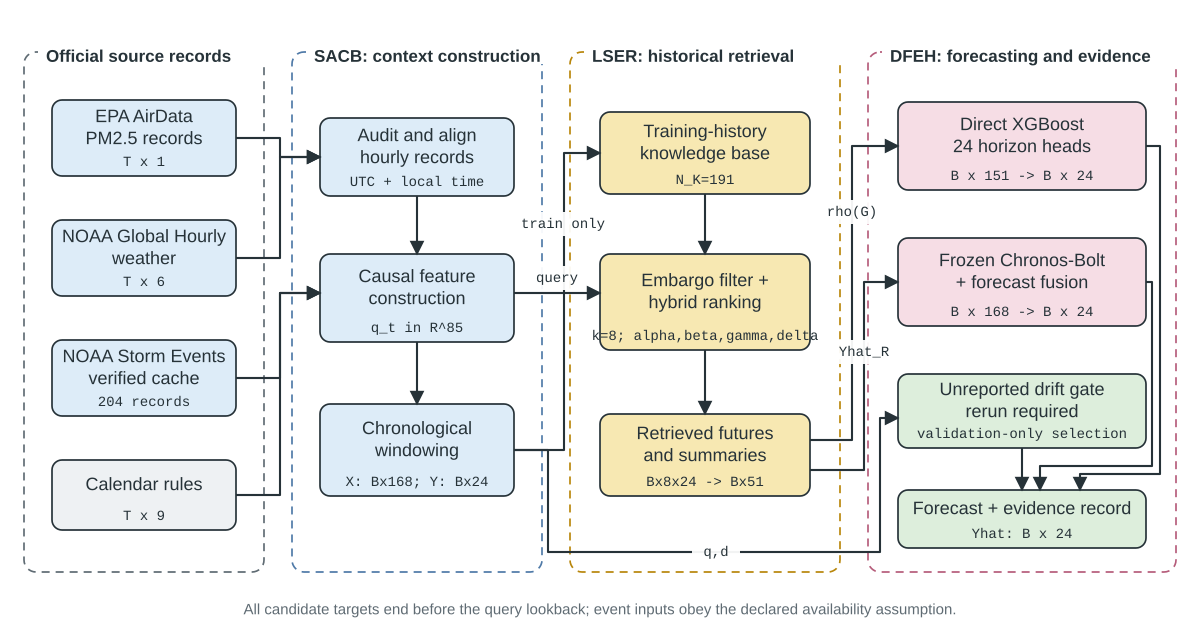

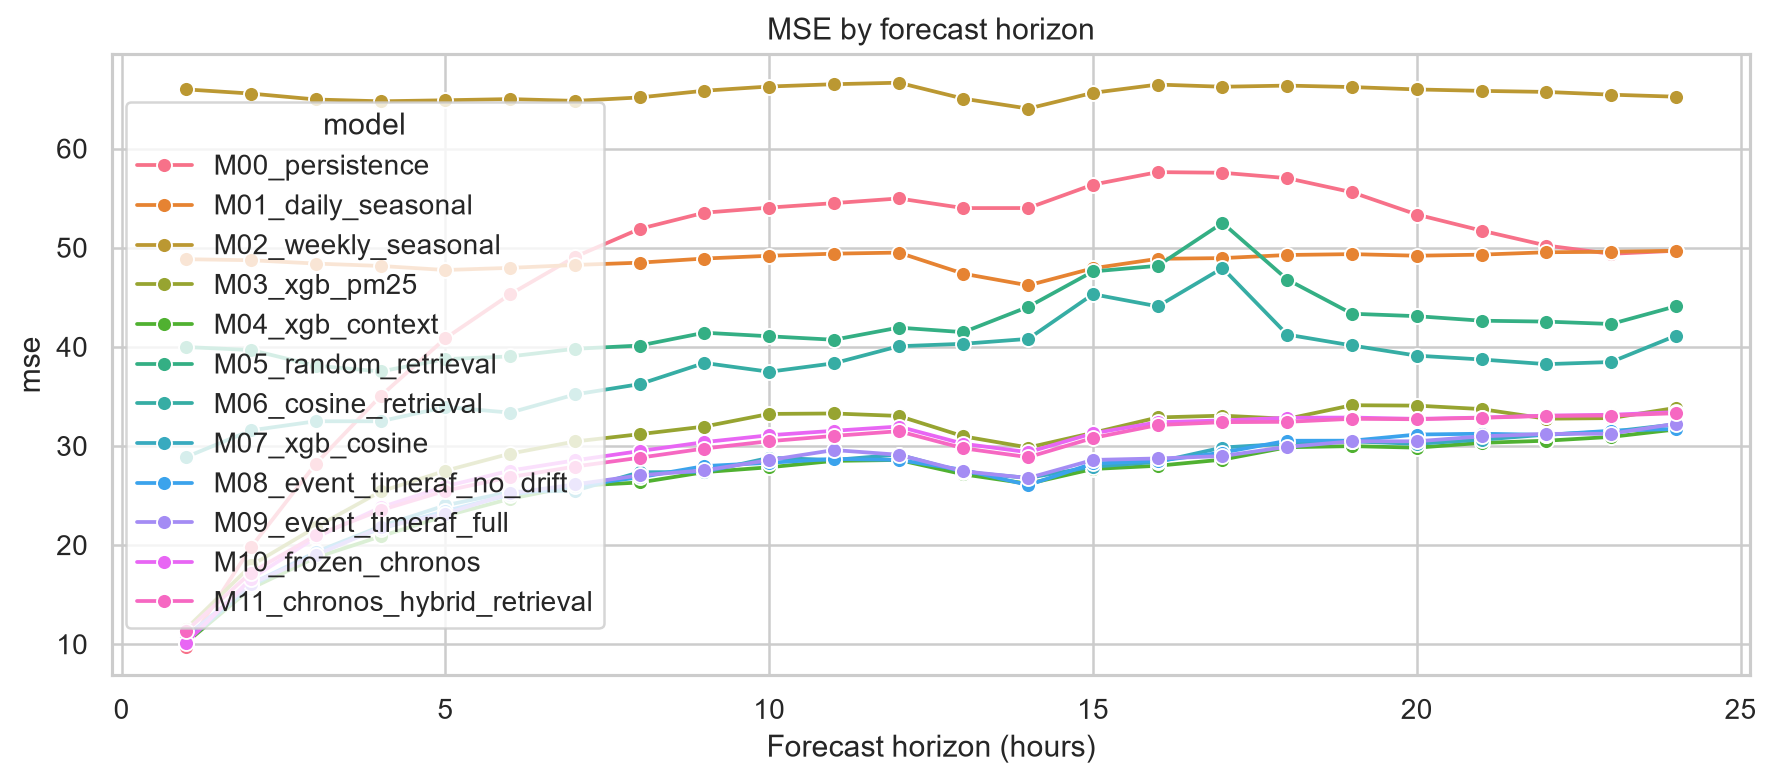

In [13]:
figure_dir = OUTPUT_ROOT / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)

# Five empirical figures.
plot_horizon_metrics(all_horizon_metrics, 'mse', figure_dir / 'mse_by_horizon.png')
plt.close()
plot_horizon_metrics(all_horizon_metrics, 'mae', figure_dir / 'mae_by_horizon.png')
plt.close()
plot_retrieval_diagnostics(retrieval_evidence, figure_dir / 'retrieval_diagnostics.png')
plt.close()
drift_frame = drift_evidence_frame(test, drift_test, manifest['run_id'])
plot_drift_scores(drift_frame, figure_dir / 'drift_scores.png')
plt.close()
case_index = int(np.argsort(np.abs(
    test.y.mean(axis=1) - predictions['M09_event_timeraf_full'].mean(axis=1)
))[len(test.y) // 2])
plot_forecast_case(
    test.x[case_index], test.y[case_index],
    {
        'Persistence': predictions['M00_persistence'][case_index],
        'XGBoost context': predictions['M04_xgb_context'][case_index],
        'Event-TimeRAF': predictions['M09_event_timeraf_full'][case_index],
    },
    figure_dir / 'forecast_case.png',
)
plt.close()

# Four vector methodology figures from the same builder used by the paper.
builder_path = PROJECT_ROOT / 'paper' / 'tools' / 'build_methodology_figures.py'
spec = importlib.util.spec_from_file_location('methodology_figures', builder_path)
methodology_figures = importlib.util.module_from_spec(spec)
spec.loader.exec_module(methodology_figures)
vector_builders = {
    'event_timeraf_pipeline_overview.svg': methodology_figures.pipeline_figure,
    'source_audited_context_builder.svg': methodology_figures.context_figure,
    'leakage_safe_event_context_retriever.svg': methodology_figures.retrieval_figure,
    'drift_aware_forecast_evidence_head.svg': methodology_figures.forecast_figure,
}
for name, builder in vector_builders.items():
    builder(figure_dir / name)

generated_figures = sorted(path.name for path in figure_dir.iterdir() if path.is_file())
display(pd.DataFrame({'generated_figure': generated_figures}))
assert len(generated_figures) == 9
display(SVG(filename=str(figure_dir / 'event_timeraf_pipeline_overview.svg')))
display(Image(filename=str(figure_dir / 'mse_by_horizon.png')))

## 11. Paper Claim Registry and Final Gate

In [14]:
m04_row = overall_results.set_index('model').loc['M04_xgb_context']
m09_row = overall_results.set_index('model').loc['M09_event_timeraf_full']
m10_row = overall_results.set_index('model').loc['M10_frozen_chronos']
m11_row = overall_results.set_index('model').loc['M11_chronos_hybrid_retrieval']
m11_boot = paper_ablation.set_index('comparison').loc['M11_minus_M10_tsfm_retrieval']

claim_registry = pd.DataFrame([
    {'claim': '48,332 windows; 7,199 test origins', 'checked_how': 'Reconstructed NPZ + metadata', 'result': 'Confirmed'},
    {'claim': '85 context features; 151 M09 inputs', 'checked_how': 'Feature names + saved M09 model', 'result': 'Corrected'},
    {'claim': 'M04 MSE/MAE/RMSE/R2 = 26.185/3.125/5.117/0.379', 'checked_how': 'Rerun joblib model + recompute metrics', 'result': 'Confirmed'},
    {'claim': 'M09 overall MSE = 26.712 and does not beat M04', 'checked_how': 'Rerun joblib model + paired ablation', 'result': 'Confirmed'},
    {'claim': 'M11 MSE = 28.709 vs M10 = 28.941', 'checked_how': 'Frozen output + validation-selected fusion', 'result': 'Confirmed'},
    {'claim': 'M11-M10 interval crosses zero', 'checked_how': '500-resample paired block bootstrap', 'result': 'Confirmed'},
    {'claim': 'Random retrieval is bitwise portable across NumPy versions', 'checked_how': 'Seed replay vs archived evidence', 'result': 'Flagged unverified'},
    {'claim': 'M12 is a final result', 'checked_how': 'Manifest membership + post-hoc log', 'result': 'Corrected: excluded'},
    {'claim': 'Events are available in strict real time', 'checked_how': 'NOAA audit availability field', 'result': 'Flagged unverified'},
    {'claim': 'Generalizes outside Los Angeles County', 'checked_how': 'Dataset inventory', 'result': 'Flagged unverified'},
    {'claim': 'Hardware-normalized efficiency', 'checked_how': 'Run manifest fields', 'result': 'Flagged unverified'},
])
display(claim_registry)
claim_registry.to_csv(OUTPUT_ROOT / 'claim_verification.csv', index=False)

paper_text = '\n'.join(
    path.read_text(encoding='utf-8')
    for path in [PROJECT_ROOT / 'paper' / 'main.tex', *sorted((PROJECT_ROOT / 'paper' / 'sections').glob('*.tex'))]
)
bibliography = (PROJECT_ROOT / 'paper' / 'references.bib').read_text(encoding='utf-8')
source_gate = {
    'wrong_86_dimension_absent': not bool(re.search(r'(R\^\{?86|86-dimensional|B\\times 86)', paper_text)),
    'wrong_152_dimension_absent': not bool(re.search(r'(152 features|B\\times 152)', paper_text)),
    'm12_result_values_absent': '26.111' not in paper_text and 'M12 drift-gated' not in paper_text,
    'reference_entries': len(re.findall(r'^@', bibliography, flags=re.MULTILINE)),
}
display(pd.DataFrame([source_gate]))
assert source_gate['wrong_86_dimension_absent']
assert source_gate['wrong_152_dimension_absent']
assert source_gate['m12_result_values_absent']
assert source_gate['reference_entries'] == 40

numerical_gate = {
    'M04_is_best_verified': overall_results.sort_values('mse').iloc[0]['model'] == 'M04_xgb_context',
    'M09_not_better_than_M04': float(m09_row['mse']) > float(m04_row['mse']),
    'M11_mse_better_than_M10': float(m11_row['mse']) < float(m10_row['mse']),
    'M11_interval_crosses_zero': float(m11_boot['ci_low']) < 0 < float(m11_boot['ci_high']),
    'all_saved_predictors_reconciled': bool(reconciliation['confirmed'].all()),
    'all_manifest_artifacts_verified': bool(integrity['sha256_match'].all()),
}
display(pd.DataFrame([numerical_gate]))
assert all(numerical_gate.values())
print('FINAL VERIFICATION STATUS: PASS WITH EXPLICIT LIMITATIONS')

,claim,checked_how,result
0,"48,332 windows; 7,199 test origins",Reconstructed NPZ + metadata,Confirmed
1,85 context features; 151 M09 inputs,Feature names + saved M09 model,Corrected
2,M04 MSE/MAE/RMSE/R2 = 26.185/3.125/5.117/0.379,Rerun joblib model + recompute metrics,Confirmed
3,M09 overall MSE = 26.712 and does not beat M04,Rerun joblib model + paired ablation,Confirmed
4,M11 MSE = 28.709 vs M10 = 28.941,Frozen output + validation-selected fusion,Confirmed
5,M11-M10 interval crosses zero,500-resample paired block bootstrap,Confirmed
6,Random retrieval is bitwise portable across Nu...,Seed replay vs archived evidence,Flagged unverified
7,M12 is a final result,Manifest membership + post-hoc log,Corrected: excluded
8,Events are available in strict real time,NOAA audit availability field,Flagged unverified
9,Generalizes outside Los Angeles County,Dataset inventory,Flagged unverified


,wrong_86_dimension_absent,wrong_152_dimension_absent,m12_result_values_absent,reference_entries
0,True,True,True,40


,M04_is_best_verified,M09_not_better_than_M04,M11_mse_better_than_M10,M11_interval_crosses_zero,all_saved_predictors_reconciled,all_manifest_artifacts_verified
0,True,True,True,True,True,True


FINAL VERIFICATION STATUS: PASS WITH EXPLICIT LIMITATIONS


## Takeaways

1. M04 is the strongest verified model; the full event-aware M09 framework does not beat it overall.
2. Retrieval is clearly better than random retrieval in the retrieval-only comparison, but adding
   retrieval/event/drift features to the strong context model does not produce a verified overall gain.
3. Frozen Chronos-Bolt fusion moves MSE in the favorable direction, but the confidence interval crosses zero.
4. Event findings are retrospective because NOAA Storm Events lacks machine-readable publication timestamps.
5. External geographic validation and recorded hardware specifications remain genuinely unverified.